In [18]:
import numpy as np
import pandas as pd
import yfinance as yf
# For plotting
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

import warnings
warnings.filterwarnings('ignore')

In [19]:
#data processing
uncleaned_data = pd.read_pickle(r"C:\Users\ankit\Downloads\NiftyOptions-Strategy-Back-testing-Solution-Files\Options-Strategy-Backtesting-Solution\nifty_options_data_2019_2022_raw")
#Error Detection and solution
uncleaned_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127605 entries, 0 to 127604
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           127605 non-null  datetime64[ns]
 1   Symbol         127605 non-null  object        
 2   Expiry         127605 non-null  object        
 3   Option Type    127605 non-null  object        
 4   Strike Price   127605 non-null  int64         
 5   Close          127605 non-null  float64       
 6   Last           127605 non-null  float64       
 7   Open Interest  127601 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 7.8+ MB


In [20]:
uncleaned_data.dropna(axis = 0, how= 'any',inplace = True)
uncleaned_data.isna().sum()


Date             0
Symbol           0
Expiry           0
Option Type      0
Strike Price     0
Close            0
Last             0
Open Interest    0
dtype: int64

In [21]:
print("portion of dulplicate count is {}%".format(round((uncleaned_data.duplicated().value_counts()[1]/(uncleaned_data.shape[0]))*100,2)))

portion of dulplicate count is 0.06%


In [22]:
#converting to date time object
uncleaned_data.Expiry= pd.to_datetime(uncleaned_data.Expiry)
#compute days to expiry
days_to_expiry= (uncleaned_data['Expiry'] - uncleaned_data['Date']).dt.days
uncleaned_data.loc[days_to_expiry<0]

,Date,Symbol,Expiry,Option Type,Strike Price,Close,Last,Open Interest
127604,2022-05-27,NIFTY,2022-05-26,PE,18150,2070.65,2070.65,1700.0


In [23]:
#resolving error 3
uncleaned_data.drop(127604)

,Date,Symbol,Expiry,Option Type,Strike Price,Close,Last,Open Interest
0,2019-01-01,NIFTY,2019-01-31,CE,8900,1455.95,0.00,0.0
1,2019-01-01,NIFTY,2019-01-31,CE,8950,1412.75,0.00,0.0
2,2019-01-01,NIFTY,2019-01-31,CE,9000,1942.65,1951.00,1096950.0
3,2019-01-01,NIFTY,2019-01-31,CE,9050,1327.70,0.00,0.0
4,2019-01-01,NIFTY,2019-01-31,CE,9100,1710.80,1710.80,6600.0
...,...,...,...,...,...,...,...,...
127599,2022-05-26,NIFTY,2022-05-26,PE,17950,1939.80,1939.80,1550.0
127600,2022-05-26,NIFTY,2022-05-26,PE,18000,1840.95,1833.90,91400.0
127601,2022-05-26,NIFTY,2022-05-26,PE,18050,1905.25,1885.00,1500.0
127602,2022-05-26,NIFTY,2022-05-26,PE,18100,1956.20,1934.10,50300.0


In [24]:
#spot data and creating bullish and bearish signals
df= pd.read_csv(r"C:\Users\ankit\Downloads\NiftyOptions-Strategy-Back-testing-Solution-Files\Options-Strategy-Backtesting-Solution\nifty_spot.csv").iloc[:41]
df['Year'] = pd.to_datetime(df['Date']).dt.strftime('%Y')
df['Month']= pd.to_datetime(df['Date']).dt.strftime('%M')
df['Date'] = pd.to_datetime(df['Date'])

In [25]:
df["SMA_5"] = df["Close"].rolling(5).mean()
bullish_condition_crossover = (df["Close"].shift(1) < df["SMA_5"].shift(1)) & (df["Close"] > df["SMA_5"])
df["Signal"] = np.where(bullish_condition_crossover,1,0)
bearish_condition_crossover = (df["Close"].shift(1) > df["SMA_5"].shift(1)) & (df["Close"] < df["SMA_5"])
df["Signal"] = np.where(bearish_condition_crossover,-1, df["Signal"])
df.head(10)

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,SMA_5,Signal
0,2019-01-02,10868.849609,10895.349609,10735.049805,10792.500000,10792.500000,309700.0,2019,00,NaN,0
1,2019-01-03,10796.799805,10814.049805,10661.250000,10672.250000,10672.250000,286200.0,2019,00,NaN,0
2,2019-01-04,10699.700195,10741.049805,10628.650391,10727.349609,10727.349609,296600.0,2019,00,NaN,0
3,2019-01-07,10804.849609,10835.950195,10750.150391,10771.799805,10771.799805,269400.0,2019,00,NaN,0
4,2019-01-08,10786.250000,10818.450195,10733.250000,10802.150391,10802.150391,277700.0,2019,00,10753.209961,0
5,2019-01-09,10862.400391,10870.400391,10749.400391,10855.150391,10855.150391,333000.0,2019,00,10765.740039,0
6,2019-01-10,10859.349609,10859.349609,10801.799805,10821.599609,10821.599609,254400.0,2019,00,10795.609961,0
7,2019-01-11,10834.750000,10850.150391,10739.400391,10794.950195,10794.950195,260800.0,2019,00,10809.130078,-1
8,2019-01-14,10807.000000,10808.000000,10692.349609,10737.599609,10737.599609,298800.0,2019,00,10802.290039,0
9,2019-01-15,10777.549805,10896.950195,10777.549805,10886.799805,10886.799805,310700.0,2019,00,10819.219922,1


In [26]:
#handling complex data
new_options_df = pd.read_pickle(r"C:\Users\ankit\Downloads\NiftyOptions-Strategy-Back-testing-Solution-Files\Options-Strategy-Backtesting-Solution\nifty_options_data_2019_2022")
new_options_df = new_options_df[new_options_df['Open Interest']>500]
new_options_df = new_options_df.reset_index()
new_options_df = new_options_df.iloc[:6256,:10]
new_options_df.head()

,Date,Symbol,Expiry,Option Type,Strike Price,Open,High,Low,Close,Last
0,2019-01-01,NIFTY,31-01-2019,CE,9000,1904.2,1951.1,1838.35,1942.65,1951.00
1,2019-01-01,NIFTY,31-01-2019,CE,9100,0.0,0.0,0.00,1710.80,1710.80
2,2019-01-01,NIFTY,31-01-2019,CE,9200,0.0,0.0,0.00,1712.70,1712.70
3,2019-01-01,NIFTY,31-01-2019,CE,9300,0.0,0.0,0.00,1608.10,1608.10
4,2019-01-01,NIFTY,31-01-2019,CE,9400,1465.8,1465.8,1453.45,1453.45,1453.45


In [138]:
new_options_daily = {}
for group_index1, sliced_df1 in new_options_df.groupby(["Date"]):
    temp2 = {}
    
    for group_index2, sliced_df2 in sliced_df1.groupby(["Option Type"]):
        strikes= []
        temp3= {}

        for group_index3, sliced_df3 in sliced_df2.groupby(["Strike Price"]):
            temp3[group_index3[0]]= sliced_df3['Close'].values[0]
        temp2[group_index2[0]]= temp3

    new_options_daily[group_index1[0].date()]= temp2

In [139]:
new_options_daily 

{datetime.date(2019, 1, 1): {'CE': {9000: np.float64(1942.65),
   9100: np.float64(1710.8),
   9200: np.float64(1712.7),
   9300: np.float64(1608.1),
   9400: np.float64(1453.45),
   9500: np.float64(1450.0),
   9600: np.float64(1353.5),
   9700: np.float64(1208.05),
   9750: np.float64(1050.0),
   9800: np.float64(1080.45),
   9900: np.float64(983.25),
   10000: np.float64(962.95),
   10100: np.float64(821.3),
   10200: np.float64(771.7),
   10300: np.float64(684.2),
   10400: np.float64(593.45),
   10450: np.float64(530.0),
   10500: np.float64(506.7),
   10550: np.float64(453.35),
   10600: np.float64(427.05),
   10650: np.float64(385.6),
   10700: np.float64(346.1),
   10750: np.float64(311.7),
   10800: np.float64(276.7),
   10850: np.float64(243.15),
   10900: np.float64(211.25),
   10950: np.float64(183.15),
   11000: np.float64(154.15),
   11050: np.float64(130.4),
   11100: np.float64(106.95),
   11150: np.float64(87.75),
   11200: np.float64(69.8),
   11250: np.float64(55.5),

In [234]:
# storing  data in   dictionary
new_trades = []
last_date = -1
# how far itm and atm strikes 
spread =200

for grouper_index, sliced_df in df.groupby(["Year","Month"]):

    cnt = 0
    trade_df = sliced_df
    last_date = trade_df.iloc[-1]['Date'].date()
    pos= 0
    new_trade = {}
    atm_strike = -1
    otm_strike = -1

    itm_strike = -1
    lot_size = 1

# Iterate through each row of the current month
for index, row in trade_df.iterrows():
    date = trade_df.iloc[cnt]['Date'].date()
    spot_price = trade_df.iloc[cnt,4]
    print(date,pos)
    
##.....******************************************************************************************************************************
    # IF THERE IS NO EXISTING POSITION
    if pos==0:
        
    # If it is not an expiry day and there is a buy signal
     if (trade_df.iloc[cnt]['Signal']==1 and date!= last_date):
         pos=1
         print("Entry date as long position",date)
         
         available_strikes = list(new_options_daily[date]['CE'].keys())
         
         difference_1 = lambda input_list : abs(input_list - spot_price)
         atm_strike = min(available_strikes, key = difference_1)

         difference_2 = lambda input_list : abs(input_list - (spot_price + spread))
         otm_strike = min(available_strikes, key = difference_2)

         new_trade['entry day']= date
         new_trade['entry Signal'] = "long"
         new_trade['spot_price_at_entry'] = spot_price
         new_trade['long_option_strike'] = atm_strike
         new_trade['short_option_strike'] = otm_strike
         new_trade['entry_long_option_premium'] = new_options_daily[date]['CE'][atm_strike]
         new_trade['entry_short_option_premium'] = new_options_daily[date]['CE'][otm_strike]
         new_trade['Entry_debit'] = lot_size* (new_trade['entry_long_option_premium']-new_trade['entry_short_option_premium'])

       # If it is not an expiry day and there is a sell signal
    if (trade_df.iloc[cnt]['Signal']==-1 and date!= last_date):
        pos= -1
        print("Entry date as Short position", date)

        available_strikes = list(new_options_daily[date]['PE'].keys())
        
        difference_1 = lambda input_list : abs(input_list - (spot_price + spread))
        itm_strike = min(available_strikes, key = difference_1)

        difference_2 = lambda input_list : abs(input_list - spot_price )
        atm_strike = min(available_strikes, key = difference_2)

        new_trade['entry day']= date
        new_trade['entry Signal'] = "short"
        new_trade['spot_price_at_entry'] = spot_price
        new_trade['long_option_strike'] = itm_strike
        new_trade['short_option_strike'] = atm_strike
        new_trade['entry_long_option_premium'] = new_options_daily[date]['PE'][itm_strike]
        new_trade['entry_short_option_premium'] = new_options_daily[date]['PE'][atm_strike]
        new_trade['Entry_debit'] = lot_size* (new_trade['entry_long_option_premium']-new_trade['entry_short_option_premium'])

          ## IF THERE IS AN OPEN POSITION 

    else:
        
  ## LONG  POSITION
      if(pos==1):

        curr_val = lot_size*(new_options_daily[date]['CE'][atm_strike] - new_options_daily[date]['CE'][otm_strike])

    ## 5 % stoploss hit

        if curr_val < 0.95*(1*new_trade['Entry_debit']):

          pos = 0
          print("Exit due to stop loss", date)

          new_trade['exit_day'] = date
          new_trade['spot_price_at_exit']= spot_price
          new_trade['exit_long_option_premium']=new_options_daily[date]['CE'][atm_strike]
          new_trade['exit_short_option_premium']=new_options_daily[date]['CE'][otm_strike]
          new_trade['Exit_credit'] = lot_size*(new_trade['exit_long_option_premium'] - new_trade['exit_short_option_premium'])

          new_trade['Profit'] = - new_trade['Entry_debit'] + new_trade['Exit_credit']
          new_trades.append(new_trade)
          new_trade = {}

              
        # Check 10 % profit target hit
          
        elif curr_val >1.1*(1* new_trade['Entry_debit']):

         pos = 0
         print("Exit date due to take-profit target hit",date)


         new_trade['exit_day'] = date
         new_trade['spot_price_at_exit']= spot_price
         new_trade['exit_long_option_premium']=new_options_daily[date]['CE'][atm_strike]
         new_trade['exit_short_option_premium']=new_options_daily[date]['CE'][otm_strike]
         new_trade['Exit_credit'] = lot_size*(new_trade['exit_long_option_premium'] - new_trade['exit_short_option_premium'])

         new_trade['Profit'] = - new_trade['Entry_debit'] + new_trade['Exit_credit']
         new_trades.append(new_trade)
         new_trade = {}

        ## ## Square off due to offsetting signal

        elif (trade_df.iloc[cnt]['Signal']==-1):

          pos= 0
          print("Exit date is for signal", date)

          new_trade['exit_date']= date
          new_trade['spot_price_at_exit']= spot_price
          new_trade['exit_long_option_premium']=new_options_daily[date]['CE'][atm_strike]
          new_trade['exit_short_option_premium']=new_options_daily[date]['CE'][otm_strike]
          new_trade['Exit_credit'] = lot_size*(new_trade['exit_long_option_premium'] - new_trade['exit_short_option_premium'])

          new_trade['Profit'] = - new_trade['Entry_debit'] + new_trade['Exit_credit']
          new_trades.append(new_trade)
          new_trade = {}  

           # Takingg  new short position based on new signal

          pos=-1
          print("Entry date in short position is", date)

          available_strikes = [strike for strike in new_options_daily[date]['PE'].keys()]
          difference_1 = lambda input_list : abs(input_list - (spot_price + spread))
          itm_strike = min(available_strikes, key = difference_1)

          difference_2 = lambda input_list : abs(input_list - spot_price )
          atm_strike = min(available_strikes, key = difference_2)

          new_trade['entry day']= date
          new_trade['entry Signal'] = "short"
          new_trade['spot_price_at_entry'] = spot_price
          new_trade['long_option_strike'] = itm_strike
          new_trade['short_option_strike'] = atm_strike
          new_trade['entry_long_option_premium'] = new_options_daily[date]['PE'][atm_strike]
          new_trade['entry_short_option_premium'] = new_options_daily[date]['PE'][otm_strike]
          new_trade['Entry_debit'] = lot_size* (new_trade['entry_long_option_premium']-new_trade['entry_short_option_premium'])

      # Square-off at the expiry day 
          
      elif (date==last_date):

          print("Exit date is for Expiry", date)

          new_trade['exit_day'] = date
          new_trade['spot_price_at_exit']= spot_price
          new_trade['exit_long_option_premium']=new_options_daily[date]['CE'][atm_strike]
          new_trade['exit_short_option_premium']=new_options_daily[date]['CE'][otm_strike]
          new_trade['Exit_credit'] = lot_size*(new_trade['exit_long_option_premium'] - new_trade['exit_short_option_premium'])

          new_trade['Profit'] = - new_trade['Entry_debit'] + new_trade['Exit_credit']
          new_trades.append(new_trade)
          new_trade = {}
          

##############################################################################################################

 # SHORT POSITION
      elif (pos==-1):

        curr_val = lot_size*(new_options_daily[date]['PE'][itm_strike]-new_options_daily[date]['PE'][atm_strike])

        if curr_val < 0.95*(1*new_trade['Entry_debit']):

          pos=0
          print("Exit due to stop loss hit",date)

          new_trade['exit_day'] = date
          new_trade['spot_price_at_exit'] = spot_price
          new_trade['exit_long_option_premium'] = new_options_daily[date]['PE'][itm_strike]
          new_trade['exit_short_option_premium'] = new_options_daily[date]['PE'][atm_strike]
          new_trade['Exit_credit'] = lot_size*(new_trade['exit_long_option_premium'] - new_trade['exit_short_option_premium'])
          new_trade['Profit'] = - new_trade['Entry_debit'] + new_trade['Exit_credit']

          new_trades.append(new_trade)
          new_trade={}
          

        elif curr_val >1.10*(1*new_trade['Entry_debit']):

          pos=0
          print("Exit due to target hit",date)


          new_trade['exit_day'] = date
          new_trade['spot_price_at_exit'] = spot_price
          new_trade['exit_long_option_premium'] = new_options_daily[date]['PE'][itm_strike]
          new_trade['exit_short_option_premium'] = new_options_daily[date]['PE'][atm_strike]
          new_trade['Exit_credit'] = lot_size*(new_trade['exit_long_option_premium'] - new_trade['exit_short_option_premium'])
          new_trade['Profit'] = - new_trade['Entry_debit'] + new_trade['Exit_credit']

          new_trades.append(new_trade)
          new_trade={}


        elif (trade_df.iloc[cnt]['Signal']==1):

         pos=0
         print("Exit date is for expiry", date)

         new_trade['exit_day'] = date
         new_trade['spot_price_at_exit'] = spot_price
         new_trade['exit_long_option_premium'] = new_options_daily[date]['PE'][itm_strike]
         new_trade['exit_short_option_premium'] = new_options_daily[date]['PE'][atm_strike]
         new_trade['Exit_credit'] = lot_size*(new_trade['exit_long_option_premium'] - new_trade['exit_short_option_premium'])
         new_trade['Profit'] = - new_trade['Entry_debit'] + new_trade['Exit_credit']

         new_trades.append(new_trade)
         new_trade={}

         pos=1
         print("Entry date in long position is", date)

         available_strikes = [strike for strike in new_options_daily[date]['CE'].keys()]
         difference_1 = lambda input_list : abs(input_list - spot_price)
         atm_strike = min(available_strikes, key = difference_1)

         difference_2 = lambda input_list : abs(input_list - (spot_price + spread))
         otm_strike = min(available_strikes, key = difference_2)

         new_trade['entry day']= date
         new_trade['entry Signal'] = "long"
         new_trade['spot_price_at_entry'] = spot_price
         new_trade['long_option_strike'] = atm_strike
         new_trade['short_option_strike'] = otm_strike
         new_trade['entry_long_option_premium'] = new_options_daily[date]['CE'][atm_strike]
         new_trade['entry_short_option_premium'] = new_options_daily[date]['CE'][otm_strike]
         new_trade['Entry_debit'] = lot_size* (new_trade['entry_long_option_premium']-new_trade['entry_short_option_premium'])


        elif (date == last_date):
            
            print("exit date is for expiry",date)
            new_trade['exit_day'] = date
            new_trade['spot_price_at_exit'] = spot_price
            new_trade['exit_long_option_premium'] = new_options_daily[date]['PE'][itm_strike]
            new_trade['exit_short_option_premium'] = new_options_daily[date]['PE'][atm_strike]
            new_trade['Exit_credit'] = lot_size*(new_trade['exit_long_option_premium'] - new_trade['exit_short_option_premium'])
            new_trade['Profit'] = - new_trade['Entry_debit'] + new_trade['Exit_credit']

            # Storing the complete trade 
            new_trades.append(new_trade)

            # Close position
            pos = 0

            # Current trade is now empty again
            new_trade = {}

#***************************************************************************************************************************

    cnt = cnt + 1

new_tradebook = pd.DataFrame(data=new_trades)
new_tradebook


             
        


2019-01-02 0
2019-01-03 0
2019-01-04 0
2019-01-07 0
2019-01-08 0
2019-01-09 0
2019-01-10 0
2019-01-11 0
Entry date as Short position 2019-01-11
2019-01-14 -1
Exit due to target hit 2019-01-14
2019-01-15 0
Entry date as long position 2019-01-15
2019-01-16 1
2019-01-17 1
2019-01-18 1
Exit due to stop loss 2019-01-18
2019-01-21 0
2019-01-22 0
2019-01-23 0
Entry date as Short position 2019-01-23
2019-01-24 -1
2019-01-25 -1
Exit due to target hit 2019-01-25
2019-01-28 0
2019-01-29 0
2019-01-30 0
2019-01-31 0
Entry date as long position 2019-01-31
2019-02-01 1
Exit date due to take-profit target hit 2019-02-01
2019-02-04 0
2019-02-05 0
2019-02-06 0
2019-02-07 0
2019-02-08 0
Entry date as Short position 2019-02-08
2019-02-11 -1
Exit due to target hit 2019-02-11
2019-02-12 0
2019-02-14 0
2019-02-15 0
2019-02-18 0
2019-02-19 0
2019-02-20 0
Entry date as long position 2019-02-20
2019-02-21 1
Exit date due to take-profit target hit 2019-02-21
2019-02-22 0
2019-02-25 0
2019-02-26 0
2019-02-27 0
En

,entry day,entry Signal,spot_price_at_entry,long_option_strike,short_option_strike,entry_long_option_premium,entry_short_option_premium,Entry_debit,exit_day,spot_price_at_exit,exit_long_option_premium,exit_short_option_premium,Exit_credit,Profit
0,2019-01-11,short,10794.950195,11000,10800,237.10,130.25,106.85,2019-01-14,10737.599609,275.35,153.95,121.40,14.55
1,2019-01-15,long,10886.799805,10900,11100,142.70,51.00,91.70,2019-01-18,10906.950195,124.55,39.95,84.60,-7.10
2,2019-01-23,short,10831.500000,11050,10850,219.50,100.45,119.05,2019-01-25,10780.549805,268.90,119.20,149.70,30.65
3,2019-01-31,long,10830.950195,10850,11050,0.85,0.05,0.80,2019-02-01,10893.650391,206.65,99.80,106.85,106.05
4,2019-02-08,short,10943.599609,11150,10950,249.55,133.80,115.75,2019-02-11,10888.799805,277.25,145.95,131.30,15.55
5,2019-02-20,long,10735.450195,10750,10950,92.70,21.20,71.50,2019-02-21,10789.849609,108.25,20.65,87.60,16.10
6,2019-02-27,short,10806.650391,11000,10800,192.55,49.50,143.05,2019-02-28,10792.500000,2.60,0.05,2.55,-140.50


In [245]:

total_wins = len(new_tradebook[new_tradebook["Profit"] > 0])
total_losses = len(new_tradebook[new_tradebook["Profit"] < 0])
total_trades = len(new_tradebook)
win_ratio = round(total_wins/total_trades,2)
loss_ratio = round(total_losses / total_trades,2)
total_win_amount = new_tradebook[new_tradebook["Profit"] > 0]["Profit"].sum()
average_profit_in_profitable_trade = total_win_amount / total_wins
total_loss_amount = new_tradebook[new_tradebook["Profit"] < 0]["Profit"].sum()
average_loss_in_loss_trade = total_loss_amount / total_losses

payoff_ratio = average_profit_in_profitable_trade / average_loss_in_loss_trade
trade_expectancy = (win_ratio * average_profit_in_profitable_trade) / (loss_ratio * average_loss_in_loss_trade)
data = [[win_ratio,loss_ratio,payoff_ratio,trade_expectancy]]
df = pd.DataFrame(data,columns=['win_ratio','loss_ratio','payoff_ratio','trade_expectancy'], index = ['value'])
df

,win_ratio,loss_ratio,payoff_ratio,trade_expectancy
value,0.71,0.29,-0.495664,-1.213522


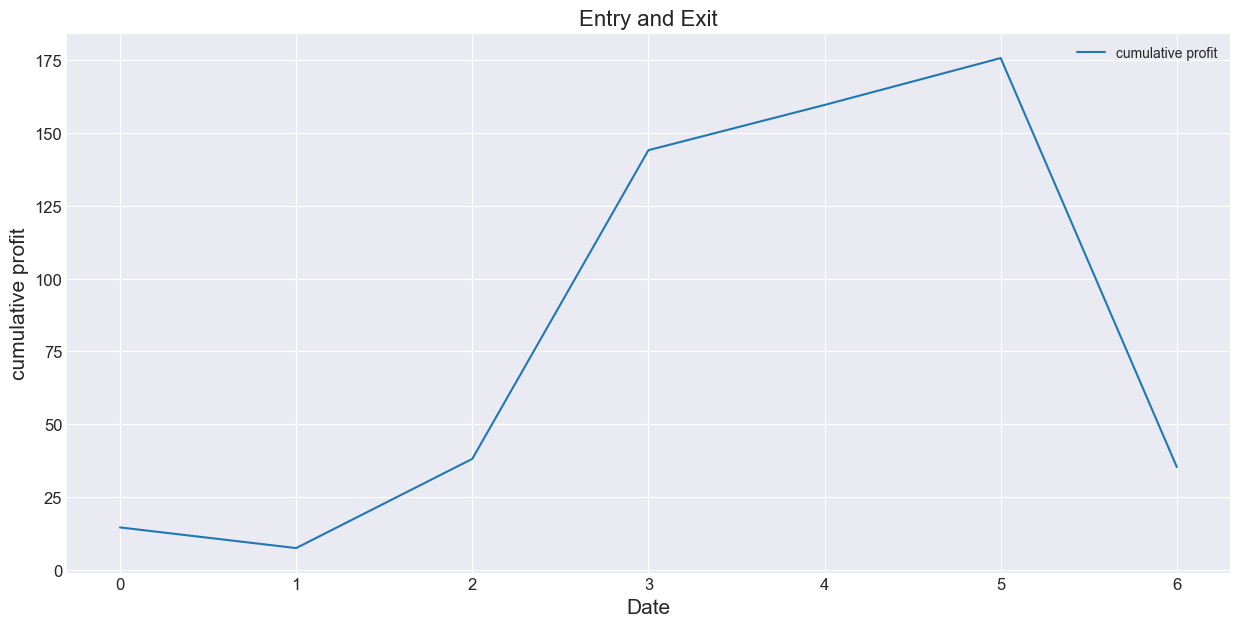

In [242]:
new_tradebook["cumulative profit"]= new_tradebook["Profit"].cumsum()

plt.figure(figsize=(15,7))
profit = new_tradebook["cumulative profit"].plot()

profit.set_title("Entry and Exit" ,fontsize = 16)
profit.set_ylabel("cumulative profit", fontsize =15)
profit.set_xlabel("Date", fontsize =15 )

plt.legend(loc='best')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()